In [2]:
import pandas as pd

In [3]:


# Load all files
studentInfo = pd.read_csv("studentInfo.csv")
studentReg = pd.read_csv("studentRegistration.csv")
studentAssess = pd.read_csv("studentAssessment.csv")
courses = pd.read_csv("courses.csv")
assessments = pd.read_csv("assessments.csv")

# Quick summary of each
for name, df in [("studentInfo", studentInfo), 
                  ("studentRegistration", studentReg),
                  ("studentAssessment", studentAssess),
                  ("courses", courses),
                  ("assessments", assessments)]:
    print(f"{'='*40}")
    print(f"FILE: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print()
# ```

# ---

# But also — let's move them to the right folder properly. In VS Code terminal run:
# ```
# move *.csv data\raw\

FILE: studentInfo
Shape: (32593, 12)
Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

FILE: studentRegistration
Shape: (32593, 5)
Columns: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']

FILE: studentAssessment
Shape: (173912, 5)
Columns: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']

FILE: courses
Shape: (22, 3)
Columns: ['code_module', 'code_presentation', 'module_presentation_length']

FILE: assessments
Shape: (206, 6)
Columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']



In [4]:
# Most important column — your target variable
print("FINAL RESULT DISTRIBUTION:")
print(studentInfo['final_result'].value_counts())
print()
print(studentInfo['final_result'].value_counts(normalize=True).mul(100).round(1))

print("\nGENDER DISTRIBUTION:")
print(studentInfo['gender'].value_counts())

print("\nAGE DISTRIBUTION:")
print(studentInfo['age_band'].value_counts())

print("\nTOP MODULES:")
print(studentInfo['code_module'].value_counts())

print("\nNULL VALUES IN studentInfo:")
print(studentInfo.isnull().sum())

FINAL RESULT DISTRIBUTION:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

final_result
Pass           37.9
Withdrawn      31.2
Fail           21.6
Distinction     9.3
Name: proportion, dtype: float64

GENDER DISTRIBUTION:
gender
M    17875
F    14718
Name: count, dtype: int64

AGE DISTRIBUTION:
age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64

TOP MODULES:
code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748
Name: count, dtype: int64

NULL VALUES IN studentInfo:
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64


In [5]:
import numpy as np

In [6]:
# ── 1. Create Churn Label ────────────────────────────────────
# Withdrawn = churned, Pass/Distinction = successful
# We'll exclude Fail for now — they're a separate segment
studentInfo['churned'] = studentInfo['final_result'].map({
    'Withdrawn': 1,
    'Pass': 0,
    'Distinction': 0,
    'Fail': 0  # we treat fail as not churned for now
})

print("CHURN DISTRIBUTION:")
print(studentInfo['churned'].value_counts())
print()

# ── 2. Handle imd_band nulls ─────────────────────────────────
# Fill missing imd_band with 'Unknown'
studentInfo['imd_band'] = studentInfo['imd_band'].fillna('Unknown')
print("imd_band nulls after fix:", studentInfo['imd_band'].isnull().sum())

# ── 3. Encode categorical columns for ML later ───────────────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ['gender', 'region', 'highest_education', 
            'imd_band', 'age_band', 'disability']

studentInfo_encoded = studentInfo.copy()
for col in cat_cols:
    studentInfo_encoded[col + '_encoded'] = le.fit_transform(studentInfo[col])

print("\nEncoded columns added successfully!")

# ── 4. Merge registration dates ──────────────────────────────
studentInfo_encoded = studentInfo_encoded.merge(
    studentReg[['id_student', 'code_module', 'code_presentation',
                'date_registration', 'date_unregistration']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

print("\nAfter merging registration data:")
print(studentInfo_encoded.shape)

# ── 5. Create early dropout flag ─────────────────────────────
# If unregistration date exists = dropped out
studentInfo_encoded['dropped_out'] = studentInfo_encoded['date_unregistration'].notnull().astype(int)
print("\nDropped out students:", studentInfo_encoded['dropped_out'].sum())

# ── 6. Merge assessment features ─────────────────────────────
# Get average score and number of assessments per student
assess_features = studentAssess.groupby('id_student').agg(
    avg_score=('score', 'mean'),
    num_assessments=('id_assessment', 'count'),
    avg_submission_day=('date_submitted', 'mean')
).reset_index()

studentInfo_encoded = studentInfo_encoded.merge(
    assess_features, on='id_student', how='left'
)

print("\nAfter merging assessment features:")
print(studentInfo_encoded.shape)
print("\nNull values in final dataset:")
print(studentInfo_encoded.isnull().sum())

# ── 7. Save cleaned data ─────────────────────────────────────
studentInfo_encoded.to_csv("cleaned.csv", index=False)
print("\n✅ Cleaned data saved!")


CHURN DISTRIBUTION:
churned
0    22437
1    10156
Name: count, dtype: int64

imd_band nulls after fix: 0

Encoded columns added successfully!

After merging registration data:
(32593, 21)

Dropped out students: 10072

After merging assessment features:
(32593, 25)

Null values in final dataset:
code_module                      0
code_presentation                0
id_student                       0
gender                           0
region                           0
highest_education                0
imd_band                         0
age_band                         0
num_of_prev_attempts             0
studied_credits                  0
disability                       0
final_result                     0
churned                          0
gender_encoded                   0
region_encoded                   0
highest_education_encoded        0
imd_band_encoded                 0
age_band_encoded                 0
disability_encoded               0
date_registration               45
date

In [7]:
# Fix remaining nulls

# 1. Registration date — fill with 0 (course start day)
studentInfo_encoded['date_registration'] = studentInfo_encoded['date_registration'].fillna(0)

# 2. Assessment nulls — students who never submitted anything
# Fill with -1 to flag them as "never engaged"
studentInfo_encoded['avg_score'] = studentInfo_encoded['avg_score'].fillna(-1)
studentInfo_encoded['num_assessments'] = studentInfo_encoded['num_assessments'].fillna(0)
studentInfo_encoded['avg_submission_day'] = studentInfo_encoded['avg_submission_day'].fillna(-1)

# 3. Create a powerful new feature — "never submitted" flag
studentInfo_encoded['never_submitted'] = (studentInfo_encoded['num_assessments'] == 0).astype(int)

print("Never submitted any assessment:", studentInfo_encoded['never_submitted'].sum())
print("Of those, how many churned?")
print(studentInfo_encoded[studentInfo_encoded['never_submitted']==1]['churned'].value_counts())

print("\nNull values remaining:")
print(studentInfo_encoded.isnull().sum().sum(), "total nulls")

# Save again
studentInfo_encoded.to_csv("cleaned.csv", index=False)
print("✅ Updated cleaned data saved!")

Never submitted any assessment: 5847
Of those, how many churned?
churned
1    4648
0    1199
Name: count, dtype: int64

Null values remaining:
22521 total nulls
✅ Updated cleaned data saved!


In [8]:
# Confirm remaining nulls are ONLY date_unregistration
print(studentInfo_encoded.isnull().sum()[studentInfo_encoded.isnull().sum() > 0])

date_unregistration    22521
dtype: int64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

df = studentInfo_encoded.copy()

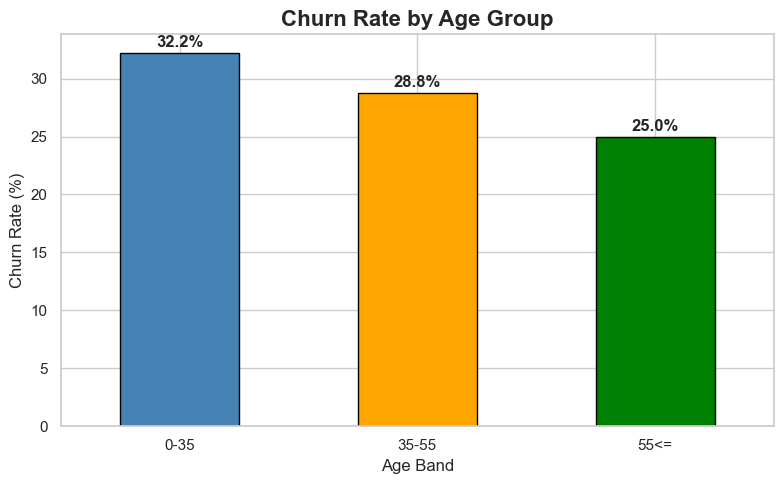

In [10]:
plt.figure(figsize=(8,5))
churn_age = df.groupby('age_band')['churned'].mean().mul(100).round(1)
churn_age.plot(kind='bar', color=['steelblue','orange','green'], edgecolor='black')
plt.title('Churn Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Band')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(churn_age):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_churn_by_age.png', dpi=150)
plt.show()

In [11]:
print(df.groupby('age_band')['churned'].mean().mul(100).round(1))

age_band
0-35     32.2
35-55    28.8
55<=     25.0
Name: churned, dtype: float64


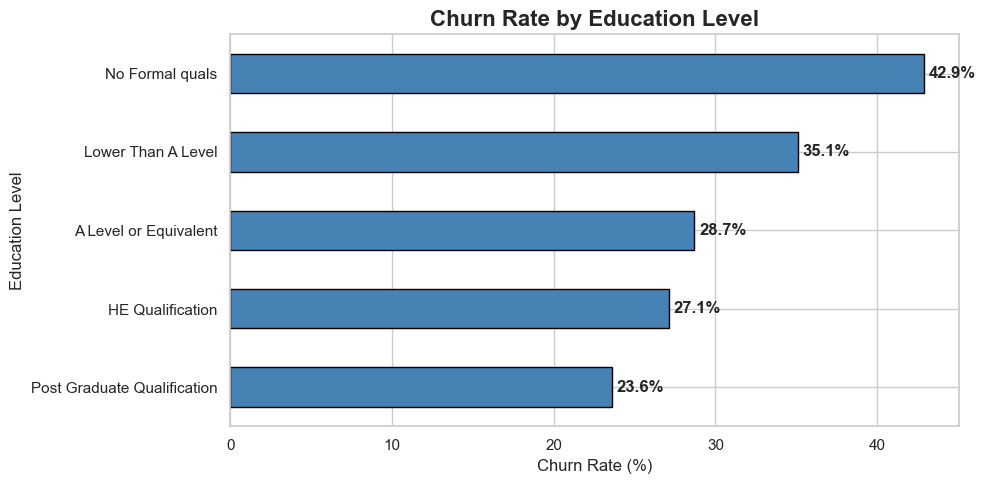

In [12]:
plt.figure(figsize=(10,5))
churn_edu = df.groupby('highest_education')['churned'].mean().mul(100).round(1).sort_values()
churn_edu.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Churn Rate by Education Level', fontsize=16, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Education Level')
for i, v in enumerate(churn_edu):
    plt.text(v+0.3, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_churn_by_education.png', dpi=150)
plt.show()

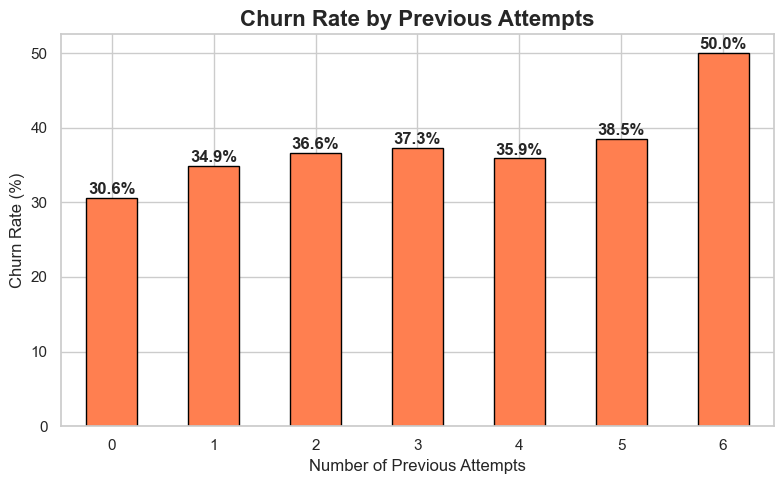

In [13]:
plt.figure(figsize=(8,5))
churn_attempts = df.groupby('num_of_prev_attempts')['churned'].mean().mul(100).round(1)
churn_attempts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Previous Attempts', fontsize=16, fontweight='bold')
plt.xlabel('Number of Previous Attempts')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(churn_attempts):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_churn_by_attempts.png', dpi=150)
plt.show()

In [14]:
print(df.groupby('num_of_prev_attempts')['churned'].mean().mul(100).round(1))
print("\nNumber of students per attempt group:")
print(df['num_of_prev_attempts'].value_counts().sort_index())

num_of_prev_attempts
0    30.6
1    34.9
2    36.6
3    37.3
4    35.9
5    38.5
6    50.0
Name: churned, dtype: float64

Number of students per attempt group:
num_of_prev_attempts
0    28421
1     3299
2      675
3      142
4       39
5       13
6        4
Name: count, dtype: int64


### 🔍 Key Finding #4 — Each Retry Increases Churn Probability
- First time students: 30.6% churn
- Second attempt: 34.9% churn  
- Third attempt: 36.6% churn
- Each additional attempt adds ~2% more churn risk
- Note: 4+ attempt groups excluded due to small sample size (n<50)

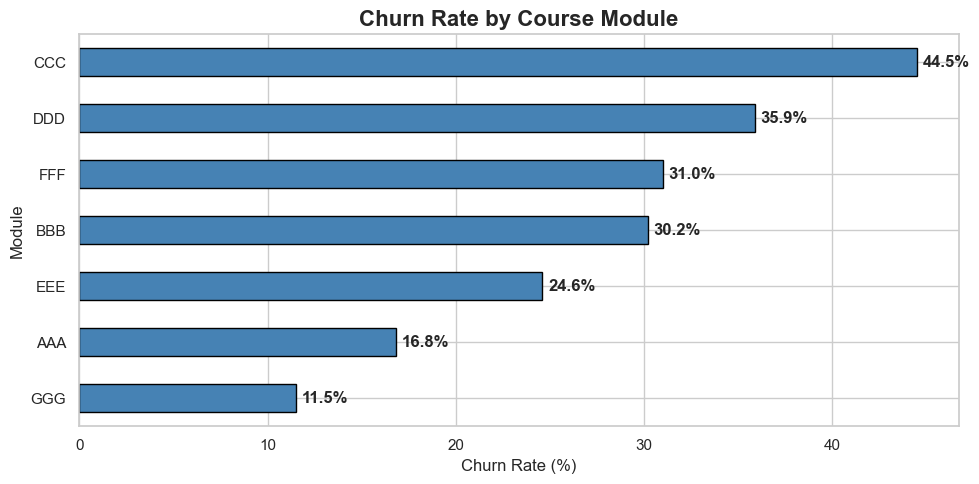

In [15]:
plt.figure(figsize=(10,5))
churn_module = df.groupby('code_module')['churned'].mean().mul(100).round(1).sort_values()
churn_module.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Churn Rate by Course Module', fontsize=16, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Module')
for i, v in enumerate(churn_module):
    plt.text(v+0.3, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_churn_by_module.png', dpi=150)
plt.show()

In [16]:
print(df.groupby('code_module')['churned'].mean().mul(100).round(1).sort_values())
print("\nStudents per module:")
print(df['code_module'].value_counts().sort_index())

code_module
GGG    11.5
AAA    16.8
EEE    24.6
BBB    30.2
FFF    31.0
DDD    35.9
CCC    44.5
Name: churned, dtype: float64

Students per module:
code_module
AAA     748
BBB    7909
CCC    4434
DDD    6272
EEE    2934
FFF    7762
GGG    2534
Name: count, dtype: int64


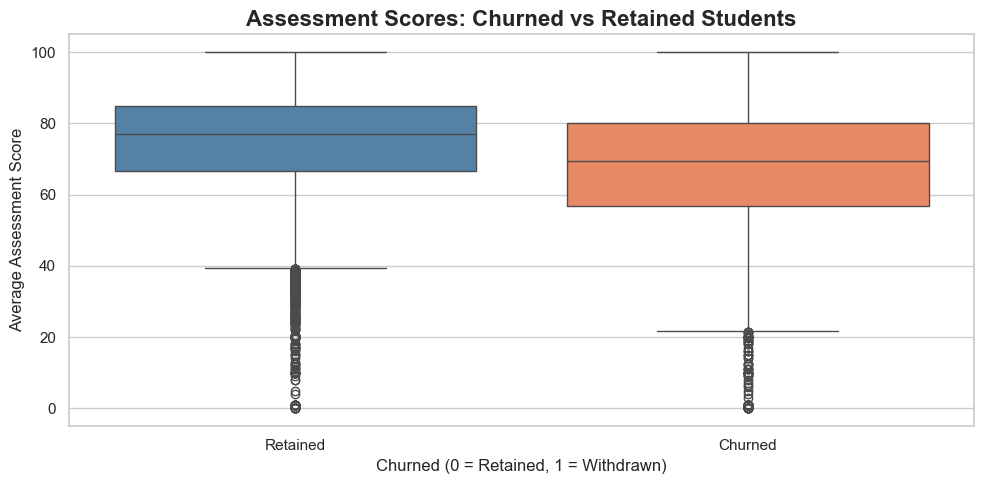

In [17]:
plt.figure(figsize=(10,5))

df_submitted = df[df['avg_score'] != -1]

sns.boxplot(data=df_submitted, x='churned', y='avg_score', 
            palette={'0':'steelblue', '1':'coral'})
plt.title('Assessment Scores: Churned vs Retained Students', 
          fontsize=16, fontweight='bold')
plt.xlabel('Churned (0 = Retained, 1 = Withdrawn)')
plt.ylabel('Average Assessment Score')
plt.xticks([0,1], ['Retained', 'Churned'])

for i, group in enumerate(['0','1']):
    mean_val = df_submitted[df_submitted['churned']==group]['avg_score'].mean()
    plt.text(i, mean_val+1, f'Mean: {mean_val:.1f}', 
             ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('chart5_score_vs_churn.png', dpi=150)
plt.show()

In [18]:
print("Mean scores:")
print(df_submitted.groupby('churned')['avg_score'].mean().round(1))



Mean scores:
churned
0    74.4
1    66.6
Name: avg_score, dtype: float64


In [19]:
# Load VLE data - sample 500k rows (it's 10M total)
vle = pd.read_csv("studentVle.csv", nrows=500000)
print("VLE Shape:", vle.shape)
print("Columns:", vle.columns.tolist())
print(vle.head())

VLE Shape: (500000, 6)
Columns: ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1


In [20]:
# Merge VLE with student info to get churn label
vle_merged = vle.merge(
    df[['id_student', 'code_module', 'code_presentation', 'churned']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

# Create weekly buckets from daily dates
vle_merged['week'] = (vle_merged['date'] // 7).astype(int)

# Total clicks per student per week
weekly_activity = vle_merged.groupby(
    ['id_student', 'code_module', 'code_presentation', 'week', 'churned']
)['sum_click'].sum().reset_index()

print("Weekly activity shape:", weekly_activity.shape)
print(weekly_activity.head(10))

Weekly activity shape: (30099, 6)
   id_student code_module code_presentation  week  churned  sum_click
0        6516         AAA             2014J    -4        0        110
1        6516         AAA             2014J    -3        0         48
2        6516         AAA             2014J    -2        0          2
3        6516         AAA             2014J    -1        0         96
4        6516         AAA             2014J     0        0        229
5        6516         AAA             2014J     1        0         42
6        6516         AAA             2014J     2        0         79
7        6516         AAA             2014J     3        0        193
8        6516         AAA             2014J     4        0         69
9        6516         AAA             2014J     5        0         34


Active students per week:
week
0     100.0
1      97.9
2     107.0
3      92.5
4      91.6
5      87.3
6      75.9
7      33.9
8      27.2
9      26.8
10     23.3
11     17.5
12     21.9
13     27.5
14     27.5
15     29.3
16     31.8
17     27.1
18     26.7
19     23.9
20     25.0
Name: id_student, dtype: float64


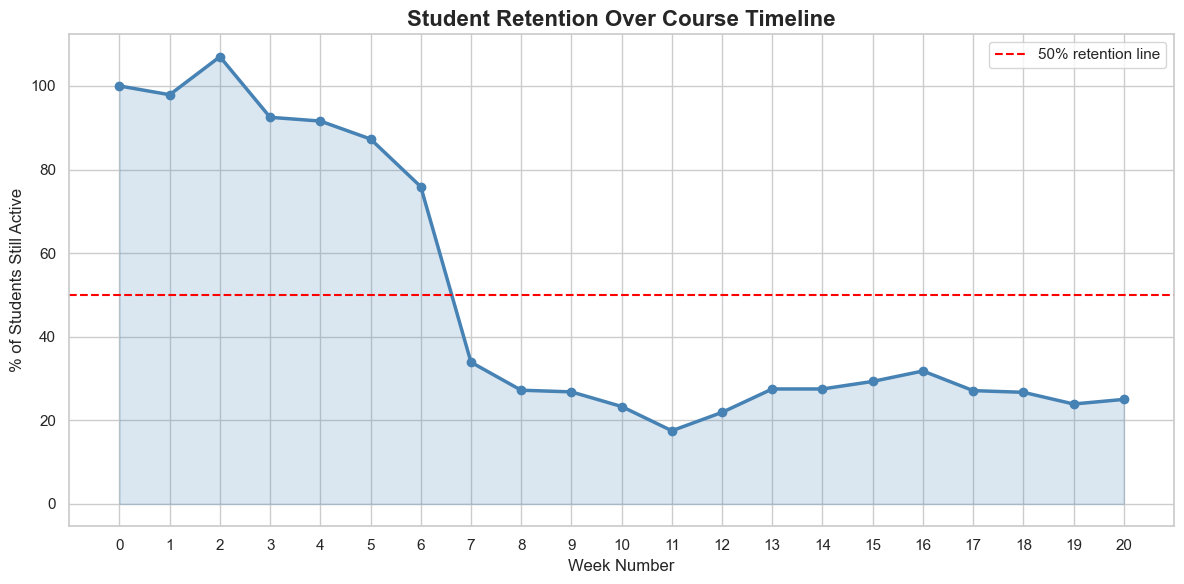

In [21]:
# Focus on weeks 0 to 20 (course duration)
weekly_filtered = weekly_activity[
    (weekly_activity['week'] >= 0) & 
    (weekly_activity['week'] <= 20)
]

# Count active students per week
active_per_week = weekly_filtered.groupby('week')['id_student'].nunique()

# Calculate retention % relative to week 0
retention = (active_per_week / active_per_week[0] * 100).round(1)

print("Active students per week:")
print(retention)

# Plot retention curve
plt.figure(figsize=(12,6))
plt.plot(retention.index, retention.values, 
         marker='o', linewidth=2.5, color='steelblue', markersize=6)
plt.fill_between(retention.index, retention.values, alpha=0.2, color='steelblue')
plt.title('Student Retention Over Course Timeline', 
          fontsize=16, fontweight='bold')
plt.xlabel('Week Number')
plt.ylabel('% of Students Still Active')
plt.axhline(y=50, color='red', linestyle='--', label='50% retention line')
plt.legend()
plt.xticks(range(0, 21))
plt.tight_layout()
plt.savefig('chart6_retention_curve.png', dpi=150)
plt.show()

Fixed retention:
week
0      93.4
1      91.5
2     100.0
3      86.4
4      85.6
5      81.6
6      70.9
7      31.6
8      25.5
9      25.1
10     21.7
11     16.4
12     20.5
13     25.7
14     25.7
15     27.4
16     29.7
17     25.4
18     24.9
19     22.3
20     23.3
Name: id_student, dtype: float64


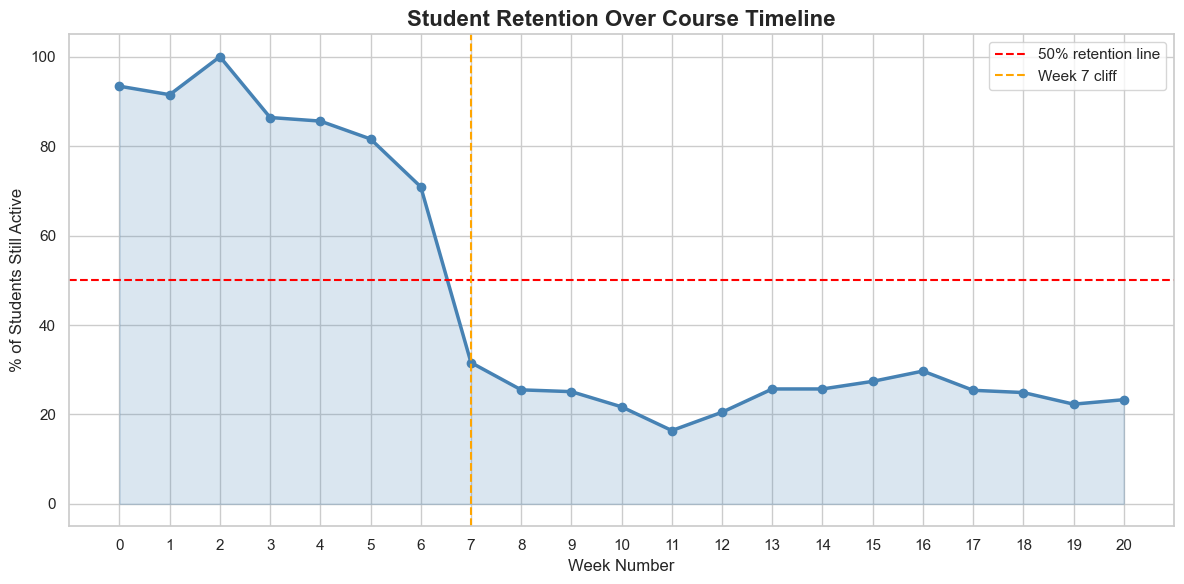

In [22]:
# Normalize properly — use max of first 3 weeks as baseline
baseline = active_per_week.iloc[:3].max()
retention = (active_per_week / baseline * 100).round(1)

# Clip anything over 100% to 100%
retention = retention.clip(upper=100)

print("Fixed retention:")
print(retention)

# Replot
plt.figure(figsize=(12,6))
plt.plot(retention.index, retention.values,
         marker='o', linewidth=2.5, color='steelblue', markersize=6)
plt.fill_between(retention.index, retention.values, alpha=0.2, color='steelblue')
plt.title('Student Retention Over Course Timeline',
          fontsize=16, fontweight='bold')
plt.xlabel('Week Number')
plt.ylabel('% of Students Still Active')
plt.axhline(y=50, color='red', linestyle='--', label='50% retention line')
plt.axvline(x=7, color='orange', linestyle='--', label='Week 7 cliff')
plt.legend()
plt.xticks(range(0, 21))
plt.tight_layout()
plt.savefig('chart6_retention_curve.png', dpi=150)
plt.show()

In [23]:
# Load assessments file
assessments = pd.read_csv("assessments.csv")
print(assessments[['code_module','assessment_type','date','weight']].sort_values('date'))

    code_module assessment_type  date  weight
41          BBB             TMA  12.0     5.0
54          CCC             CMA  18.0     2.0
64          CCC             CMA  18.0     2.0
0           AAA             TMA  19.0    10.0
48          BBB             TMA  19.0     0.0
..          ...             ...   ...     ...
62          CCC            Exam   NaN   100.0
63          CCC            Exam   NaN   100.0
72          CCC            Exam   NaN   100.0
73          CCC            Exam   NaN   100.0
108         DDD            Exam   NaN   100.0

[206 rows x 4 columns]


In [24]:
# Week 7 = days 42 to 49
week7_assessments = assessments[
    (assessments['date'] >= 42) & 
    (assessments['date'] <= 56)
]
print("Assessments around week 7:")
print(week7_assessments[['code_module','assessment_type','date','weight']].sort_values('date'))

Assessments around week 7:
    code_module assessment_type  date  weight
18          BBB             TMA  47.0    18.0
30          BBB             TMA  47.0    18.0
36          BBB             CMA  47.0     1.0
145         FFF             TMA  47.0    12.5
132         FFF             TMA  47.0    12.5
75          DDD             CMA  51.0     3.0
158         FFF             TMA  52.0    12.5
171         FFF             TMA  52.0    12.5
82          DDD             TMA  53.0    10.0
96          DDD             TMA  53.0    12.5
89          DDD             TMA  53.0    12.5
49          BBB             TMA  54.0    10.0
1           AAA             TMA  54.0    20.0
24          BBB             CMA  54.0     1.0
7           AAA             TMA  54.0    20.0
12          BBB             CMA  54.0     1.0


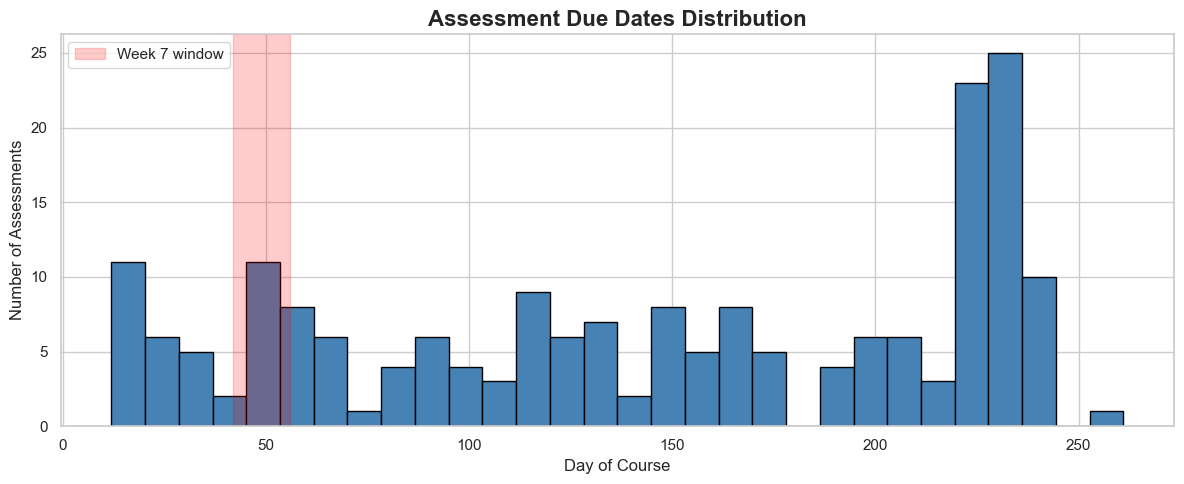

In [25]:
# Distribution of assessment dates
assessments_clean = assessments.dropna(subset=['date'])
plt.figure(figsize=(12,5))
plt.hist(assessments_clean['date'], bins=30, color='steelblue', edgecolor='black')
plt.axvspan(42, 56, color='red', alpha=0.2, label='Week 7 window')
plt.title('Assessment Due Dates Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Day of Course')
plt.ylabel('Number of Assessments')
plt.legend()
plt.tight_layout()
plt.savefig('chart7_assessment_dates.png', dpi=150)
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Features we'll use to predict churn
features = [
    'gender_encoded',
    'region_encoded', 
    'highest_education_encoded',
    'imd_band_encoded',
    'age_band_encoded',
    'num_of_prev_attempts',
    'studied_credits',
    'disability_encoded',
    'date_registration',
    'avg_score',
    'num_assessments',
    'avg_submission_day',
    'never_submitted'
]

target = 'churned'

# Prepare data
X = df[features]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (32593, 13)
Target distribution:
churned
0    22437
1    10156
Name: count, dtype: int64


In [27]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]:,} students")
print(f"Test set: {X_test.shape[0]:,} students")

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'  # handles imbalanced churn vs retained
)
model.fit(X_train, y_train)
print("\n✅ Model trained!")

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

Training set: 26,074 students
Test set: 6,519 students

✅ Model trained!

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4488
           1       0.72      0.69      0.70      2031

    accuracy                           0.82      6519
   macro avg       0.79      0.78      0.79      6519
weighted avg       0.82      0.82      0.82      6519

ROC-AUC Score: 0.895


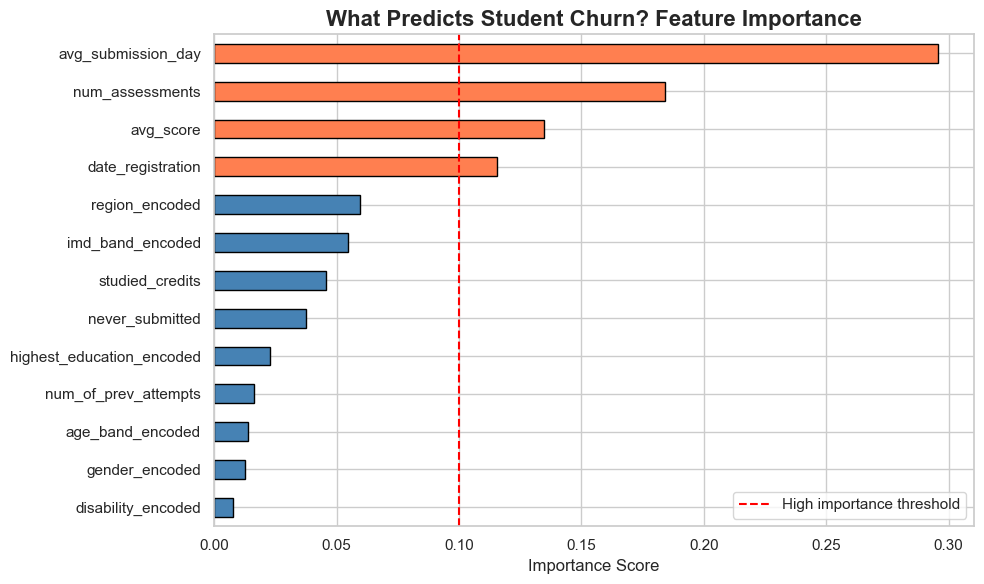


FEATURE IMPORTANCE RANKING:
avg_submission_day           0.296
num_assessments              0.184
avg_score                    0.135
date_registration            0.115
region_encoded               0.059
imd_band_encoded             0.055
studied_credits              0.046
never_submitted              0.037
highest_education_encoded    0.023
num_of_prev_attempts         0.016
age_band_encoded             0.014
gender_encoded               0.013
disability_encoded           0.008
dtype: float64


In [28]:
# Feature importance chart
importance = pd.Series(
    model.feature_importances_, 
    index=features
).sort_values()

plt.figure(figsize=(10,6))
colors = ['coral' if x > 0.1 else 'steelblue' for x in importance.values]
importance.plot(kind='barh', color=colors, edgecolor='black')
plt.title('What Predicts Student Churn? Feature Importance', 
          fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(x=0.1, color='red', linestyle='--', label='High importance threshold')
plt.legend()
plt.tight_layout()
plt.savefig('chart8_feature_importance.png', dpi=150)
plt.show()

# Print exact values
print("\nFEATURE IMPORTANCE RANKING:")
print(importance.sort_values(ascending=False).round(3))

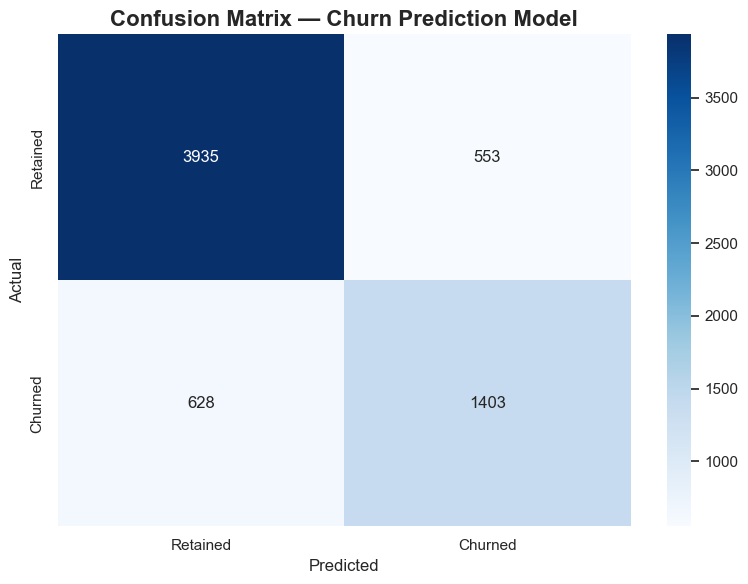

✅ Correctly identified students who stayed: 3,935
✅ Correctly identified students who churned: 1,403
⚠️ False alarms (said churn, actually stayed): 553
❌ Missed churners (said stay, actually churned): 628


In [29]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix — Churn Prediction Model',
          fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('chart9_confusion_matrix.png', dpi=150)
plt.show()

# Business translation
tn, fp, fn, tp = cm.ravel()
print(f"✅ Correctly identified students who stayed: {tn:,}")
print(f"✅ Correctly identified students who churned: {tp:,}")
print(f"⚠️ False alarms (said churn, actually stayed): {fp:,}")
print(f"❌ Missed churners (said stay, actually churned): {fn:,}")

In [30]:
# Summary of all findings and recommendations
findings = {
    'Finding 1': {
        'insight': '79.5% of students who never submitted an assessment withdrew',
        'impact': 'High - early identifier of at-risk students',
        'recommendation': 'Flag non-submitters by Day 7 for immediate tutor outreach'
    },
    'Finding 2': {
        'insight': 'Younger students (0-35) churn most despite being largest group',
        'impact': 'High - affects 70% of student base',
        'recommendation': 'Gamification, peer communities, flexible deadlines for younger cohorts'
    },
    'Finding 3': {
        'insight': 'No formal qualifications = highest churn rate',
        'impact': 'Medium - targeted support opportunity',
        'recommendation': 'Pre-course foundation modules for students with no formal quals'
    },
    'Finding 4': {
        'insight': 'Each retry attempt adds ~2% churn risk',
        'impact': 'Medium - repeat attempters need different support',
        'recommendation': 'Mandatory counseling session for students with 2+ previous attempts'
    },
    'Finding 5': {
        'insight': 'CCC module has 44.5% churn vs GGG 11.5%',
        'impact': 'Critical - 33 point gap between modules',
        'recommendation': 'Urgent audit of CCC. Replicate GGG approach across high churn modules'
    },
    'Finding 6': {
        'insight': 'Churned students score 7.8 points lower on average',
        'impact': 'High - early performance predicts outcome',
        'recommendation': 'Flag students scoring below 50 in first assessment for support'
    },
    'Finding 7': {
        'insight': 'Week 7 cliff — 39% drop in active students in one week',
        'impact': 'Critical - biggest single dropout event',
        'recommendation': 'Maximum intervention push in weeks 5-6 before cliff hits'
    },
    'Finding 8': {
        'insight': 'Week 7 cliff caused by multiple high-weight assessment deadlines',
        'impact': 'Critical - structural course design issue',
        'recommendation': 'Stagger assessment deadlines, break high-weight TMAs into milestones'
    },
    'Finding 9': {
        'insight': 'Behavior beats demographics in predicting churn',
        'impact': 'Critical - changes intervention strategy',
        'recommendation': 'Build early warning system based on assessment behavior not demographics'
    }
}

for finding, details in findings.items():
    print(f"{'='*60}")
    print(f"🔍 {finding}")
    print(f"   Insight:        {details['insight']}")
    print(f"   Impact:         {details['impact']}")
    print(f"   Recommendation: {details['recommendation']}")
print(f"{'='*60}")

🔍 Finding 1
   Insight:        79.5% of students who never submitted an assessment withdrew
   Impact:         High - early identifier of at-risk students
   Recommendation: Flag non-submitters by Day 7 for immediate tutor outreach
🔍 Finding 2
   Insight:        Younger students (0-35) churn most despite being largest group
   Impact:         High - affects 70% of student base
   Recommendation: Gamification, peer communities, flexible deadlines for younger cohorts
🔍 Finding 3
   Insight:        No formal qualifications = highest churn rate
   Impact:         Medium - targeted support opportunity
   Recommendation: Pre-course foundation modules for students with no formal quals
🔍 Finding 4
   Insight:        Each retry attempt adds ~2% churn risk
   Impact:         Medium - repeat attempters need different support
   Recommendation: Mandatory counseling session for students with 2+ previous attempts
🔍 Finding 5
   Insight:        CCC module has 44.5% churn vs GGG 11.5%
   Impact:      

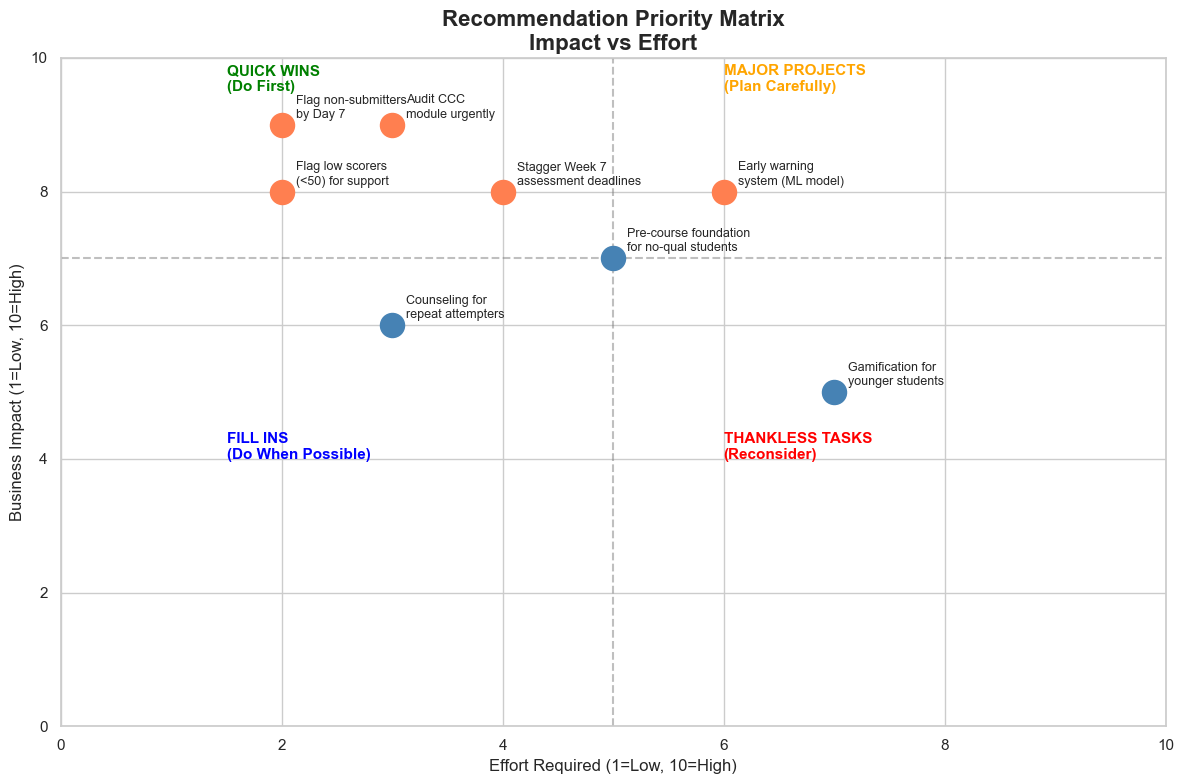

In [31]:
# Priority matrix — Impact vs Effort
recommendations = {
    'Flag non-submitters\nby Day 7': (9, 2),
    'Audit CCC\nmodule urgently': (9, 3),
    'Stagger Week 7\nassessment deadlines': (8, 4),
    'Early warning\nsystem (ML model)': (8, 6),
    'Pre-course foundation\nfor no-qual students': (7, 5),
    'Counseling for\nrepeat attempters': (6, 3),
    'Gamification for\nyounger students': (5, 7),
    'Flag low scorers\n(<50) for support': (8, 2),
}

fig, ax = plt.subplots(figsize=(12, 8))

for rec, (impact, effort) in recommendations.items():
    ax.scatter(effort, impact, s=300, 
               color='coral' if impact >= 8 else 'steelblue',
               zorder=5)
    ax.annotate(rec, (effort, impact), 
                textcoords="offset points",
                xytext=(10, 5), fontsize=9)

# Quadrant lines
ax.axhline(y=7, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(1.5, 9.5, 'QUICK WINS\n(Do First)', fontsize=11, 
        color='green', fontweight='bold')
ax.text(6, 9.5, 'MAJOR PROJECTS\n(Plan Carefully)', fontsize=11, 
        color='orange', fontweight='bold')
ax.text(1.5, 4, 'FILL INS\n(Do When Possible)', fontsize=11, 
        color='blue', fontweight='bold')
ax.text(6, 4, 'THANKLESS TASKS\n(Reconsider)', fontsize=11, 
        color='red', fontweight='bold')

ax.set_xlabel('Effort Required (1=Low, 10=High)', fontsize=12)
ax.set_ylabel('Business Impact (1=Low, 10=High)', fontsize=12)
ax.set_title('Recommendation Priority Matrix\nImpact vs Effort', 
             fontsize=16, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
plt.tight_layout()
plt.savefig('chart10_priority_matrix.png', dpi=150)
plt.show()